
# Convolution begrijpen door te kijken

In deze opdracht ga je **zien** wat een convolutionele laag doet met een afbeelding.


In pytorch werken we met tensors.
- Een tensor is een geordende verzameling getallen met een vaste vorm.
- Tensors hebben een dimensie
- Tensors hebben een shape

We importeren de benodigde libraries.

In [ ]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


1. Geef een voorbeeld van een 0D datastructuur p / een scalar in python code. 
Wat gebeurt er als je `print(p.shape)` doet? Waarom?

2. Geef een voorbeeld van een 1D datastructuur / vector in python code. Gebruik een gewone lijst in Python. Wat gebeurt er als je `.shape` probeert te printen? En als je er nu een numpy array van maakt?

3. Geef een voorbeeld van een 2D datastructuur / matrix in python code gebruikmakend van numpy. Print de `.shape` .

4. Als we nu meerdere matrices op elkaar stapelen en meerdere batches batches hebben gebruiken we een tensor. Je kunt een numpy matrix converteren naar een tensor (gebruik een functie uit de `tourch` library). Converteer matrix naar een tensor en print de `.shape` van de tensor. Wat valt je op?


In [ ]:
##Geef een voorbeeld van een scalar in python code.
p = np.int8(5)
print(p.shape)

##Geef een voorbeeld van een vector in python code.
v = np.array([1, 2, 3])
print(v.shape)

##Geef een voorbeeld van een matrix in python code (numpy) en print de shape.
m = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(m.shape)

##Converteer de matrix uit de vorige vraag naar een tensor en print de shape.
t = torch.tensor(m)
print(t.shape)

# In een tensor is de size een array ipv een tuple.


PyTorch gebruikt 4D tensors voor afbeeldingen.
Hoewel een afbeelding dus 2D is komen er de volgende demensies bij:

**Batch (B)**

Het netwerk wil meerdere afbeeldingen tegelijk kunnen verwerken
Ook als je er maar één hebt moet je dus 1 opgeven

**Channels (C)**

Een afbeelding bestaat uit kanalen (grijs = 1, zoals bij MNIST), maar wat zijn dan bijvoorbeeld 3 kanalen denk je?

- RGB is een voorbeeld van 3 kanalen

Dus zo'n 4D afbeelding moet de volgende dementies hebben (B, C, H, W)

5. Converteer nu de 2D tensor die je hierboven hebt gemaakt naar een 4D tensor. Omdat we maar 1 afbeelding en een kanaal hebben zou het dus (1, 1, Height, Width) moeten zijn.
Tip: kijk naar de functie `unsqueeze(0)`. je kunt `.shape` gebruiken om te controleren of de formaat die je eruit hebt klopt. 

In [ ]:
##zorg er voor dat de 2D matrix van de vorige vraag een 4D tensor wordt met de volgende shape: (1, 1, 3, 3)
tensor_4d = t.unsqueeze(0).unsqueeze(0)

print(tensor_4d.shape)


## Opdracht 1 — Eén convolutionele laag

We bekijken een extreem simpel neuraal netwerk:
- 1 convolutionele laag
- geen training
- alleen kijken naar de output


### Stap 1: Begrijp het netwerk
Lees onderstaande code aandachtig.


In [ ]:

class SimpleConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 4, 3, padding=1)

    def forward(self, x):
        # intern gebeurt dit: self.conv.forward(x)
        return self.conv(x)



### Vragen (beantwoord zonder code uit te voeren)

6. Hoeveel **filters** zitten in deze laag?

- Er zitten 4 filters in de laag omdat er 4 output kanalen zijn.

7. Wat is de **kernel size** van elk filter?

- De kernal size is 3, omdat dat is meegegeven in de self.conv2d functie.

8. Waarom is `padding=1` hier logisch?

- Omdat de kernal size en output moeten gelijk blijven, is padding 1 logisch.

9. Als de input `(1, 1, 128, 128)` is, wat is dan de **vorm van de output**?

- Er zijn 4 output kanalen, daarom is de output vorm (1, 4, 128, 128)




### Stap 2: Input voorbereiden

We hebben één grijswaarden-afbeelding genaamd `image`.
De plotting-code krijg je al.

10. Je maakt een lege afbeelding aan van 128 bij 128 door gebruik te maken van `image = np.zeros`.
Teken er nu met code een gevulde vierkant of een rechthoek in door bepaalde pixels op 1 te zetten. 


11. Maar er een 4D tensor van zoals we in de eerdere opdracht hebben gedaan

torch.Size([1, 1, 128, 128])


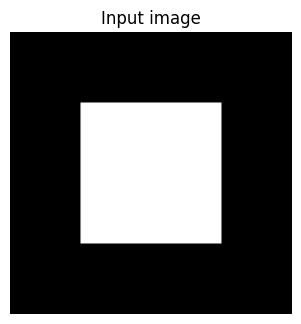

In [10]:

# gegeven: een afbeelding met shape (H, W)
H, W = 128, 128

# maak eerst een lege afbeelding door alle pixels leeg te laten
image = np.zeros((H, W), dtype=np.float32)

## pas de afbeelding nu zelf aan - maak een vierkant door bepaalde pixels op 1.0 te zetten

image[32:96, 32:96] = 1.0

# toon je afbeelding (zou nu een witte vierkant op ene zwarte achtergrond moeten zijn)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Input image")
plt.imshow(image, cmap='gray')
plt.axis('off')

# maak een tensor van
x = torch.tensor(image)
## schrijf een stukje code die onze tensor x omzet naar de benodigde vorm

x = x.unsqueeze(0).unsqueeze(0)

##print de x nu

print(x.shape)



### Stap 3: Forward pass en visualisatie

We laten de afbeelding door de convolutionele laag lopen
en plotten elke feature map.


Bekijk de plots goed en denk na over wat je ziet.


tensor([[[-0.2260,  0.1731, -0.1653],
         [ 0.0061, -0.1954, -0.2875],
         [-0.3001, -0.1384,  0.2079]]], grad_fn=<SelectBackward0>)


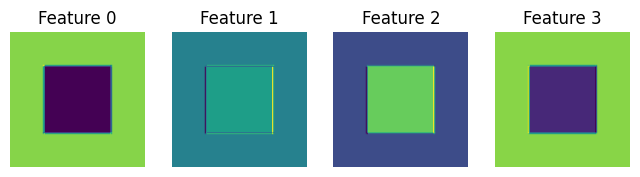

In [40]:

model = SimpleConv()

# toon hier een random kernel
print(model.conv.weight[0])


# model(x) roept automatisch model.forward(x) aan
# detach() gebruik je als je een tensor alleen wilt bekijken en niet wilt trainen.
# we kiezen [0] de demensie omdat dat de batch is (en er is maar 1)
feat = model(x).detach().numpy()[0]

plt.figure(figsize=(8, 3))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f"Feature {i}")
    plt.imshow(feat[i], cmap="viridis")
    plt.axis("off")
plt.show()



### Vragen

12. We kunnen de 0 in `model.conv.weight[0]` ook door andere getallen vervangen. Waarom ? 

- Omdat er 4 filters zijn. Kan je kijken naar de output van elk filter door het getal te veranderen.

13. Waarom krijgen we **vier** afbeeldingen te zien?

- Omdat er 4 filters(outputs) zijn

14. Lijken deze feature maps op de originele afbeelding? Waarom wel / niet?

- De feature maps lijken qua vorm wel op de originele afbeelding, maar zijn qua kleur en details anders. Dit komt omdat het model bepaalde kenmerken versterkt of onderdrukt.

15. Rund het laatste stukje nog een keer. Veranderen de afbeeldingen? Waarom?

- De afbeeldingen veranderen omdat er elke keer nieuwe gewichten gegenereerd worden. Hierdoor is de output elke keer anders. 


